# Módulo 1 Diagnóstico de treino em Deep Learning

**Curso:** Otimização, Regularização e Ajuste de Modelos Profundos  
**Foco desta aula:** diagnosticar problemas de treino antes de “tunar tudo”.

## Objetivos de aprendizagem
Ao final deste notebook, você deverá conseguir:

1. Diferenciar **underfitting** e **overfitting** por meio das curvas de treino/validação.
2. Medir e interpretar **gap de generalização** e relacionar com **viés–variância**.
3. Avaliar modelos com métricas além de acurácia (**F1, AUC, calibration/ECE**).
4. Identificar sinais de instabilidade de treino:  
   - gradientes que **explodem**  
   - gradientes que **somem** (vanishing)  
   - **loss oscilando** por hiperparâmetros inadequados.

> **Dica didática:** use este notebook em aula alternando explicação e execução de cada bloco.

---
## 0) Preparação do ambiente

In [ ]:
!pip install torch torchvision scikit-learn matplotlib pandas numpy

: 

In [ ]:

# Se necessário, descomente:
# !pip install torch torchvision scikit-learn matplotlib pandas numpy

import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay
)
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.calibration import calibration_curve
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

# Configuração de visualização
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

: 

In [ ]:

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

: 

---
## 1) Utilitários: dados, modelo, métricas e treino


In [ ]:

def make_torch_loaders(
    X: np.ndarray, y: np.ndarray,
    batch_size: int = 64,
    valid_size: float = 0.3,
    stratify: bool = True,
    seed: int = 42
):
    y_strat = y if stratify else None
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, test_size=valid_size, random_state=seed, stratify=y_strat
    )

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)

    X_va_t = torch.tensor(X_va, dtype=torch.float32)
    y_va_t = torch.tensor(y_va, dtype=torch.float32).view(-1, 1)

    train_ds = TensorDataset(X_tr_t, y_tr_t)
    valid_ds = TensorDataset(X_va_t, y_va_t)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_dl = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)
    return train_dl, valid_dl, (X_tr, X_va, y_tr, y_va)

: 

In [26]:

class MLPBinary(nn.Module):
    """
    MLP para classificação binária.
    - hidden_sizes: lista com tamanhos das camadas ocultas
    - activation: 'relu' ou 'tanh' ou 'sigmoid'
    - dropout: taxa de dropout
    - batch_norm: se True, adiciona BatchNorm após camada linear
    """
    def __init__(
        self,
        in_dim: int,
        hidden_sizes: List[int],
        activation: str = "relu",
        dropout: float = 0.0,
        batch_norm: bool = False
    ):
        super().__init__()
        acts = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "sigmoid": nn.Sigmoid
        }
        if activation not in acts:
            raise ValueError(f"Ativação inválida: {activation}")

        layers = []
        prev = in_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(acts[activation]())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, 1))  # logit final
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [27]:

def expected_calibration_error(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_bins: int = 10
) -> float:
    """
    ECE (Expected Calibration Error) simples:
    ECE = soma_k (|acc_k - conf_k| * (n_k / n_total))
    """
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    n = len(y_true)

    for b in range(n_bins):
        mask = bin_ids == b
        if np.any(mask):
            acc = np.mean(y_true[mask] == (y_prob[mask] >= 0.5))
            conf = np.mean(y_prob[mask])
            ece += np.abs(acc - conf) * (np.sum(mask) / n)
    return float(ece)

def binary_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> Dict[str, float]:
    y_pred = (y_prob >= threshold).astype(int)
    # Em casos extremos (classe única na validação), AUC pode falhar
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = np.nan

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": auc,
        "brier": brier_score_loss(y_true, y_prob),
        "ece": expected_calibration_error(y_true, y_prob, n_bins=10),
    }

In [28]:

@dataclass
class TrainConfig:
    epochs: int = 100
    lr: float = 1e-3
    batch_size: int = 64
    weight_decay: float = 0.0
    optimizer: str = "adam"  # 'adam' ou 'sgd'
    momentum: float = 0.9
    grad_clip: Optional[float] = None
    verbose_every: int = 20

def get_optimizer(model: nn.Module, cfg: TrainConfig):
    if cfg.optimizer.lower() == "adam":
        return torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    elif cfg.optimizer.lower() == "sgd":
        return torch.optim.SGD(model.parameters(), lr=cfg.lr, momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    else:
        raise ValueError("optimizer deve ser 'adam' ou 'sgd'.")

def evaluate_model(model: nn.Module, dl: DataLoader, loss_fn):
    model.eval()
    losses, probs, y_true = [], [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            p = torch.sigmoid(logits)

            losses.append(loss.item())
            probs.append(p.cpu().numpy().ravel())
            y_true.append(yb.cpu().numpy().ravel())

    y_prob = np.concatenate(probs)
    y_true = np.concatenate(y_true).astype(int)
    metrics = binary_metrics(y_true, y_prob, threshold=0.5)
    return float(np.mean(losses)), metrics, y_true, y_prob

def train_model(
    model: nn.Module,
    train_dl: DataLoader,
    valid_dl: DataLoader,
    cfg: TrainConfig,
    return_grad_history: bool = True
):
    model.to(device)
    loss_fn = nn.BCEWithLogitsLoss()
    opt = get_optimizer(model, cfg)

    history = {
        "epoch": [],
        "train_loss": [], "valid_loss": [],
        "train_acc": [], "valid_acc": [],
        "train_f1": [], "valid_f1": [],
        "train_auc": [], "valid_auc": [],
        "train_ece": [], "valid_ece": [],
        "generalization_gap_acc": [],
        "grad_norm_mean": [], "grad_norm_max": []
    }

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        batch_losses = []
        grad_norms = []

        y_prob_train, y_true_train = [], []

        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()

            # Medição de norma dos gradientes (sinal de estabilidade/instabilidade)
            total_norm_sq = 0.0
            max_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    gnorm = p.grad.data.norm(2).item()
                    total_norm_sq += gnorm ** 2
                    max_norm = max(max_norm, gnorm)
            total_norm = math.sqrt(total_norm_sq)
            grad_norms.append((total_norm, max_norm))

            if cfg.grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

            opt.step()

            batch_losses.append(loss.item())
            y_prob_train.append(torch.sigmoid(logits).detach().cpu().numpy().ravel())
            y_true_train.append(yb.detach().cpu().numpy().ravel())

        y_prob_train = np.concatenate(y_prob_train)
        y_true_train = np.concatenate(y_true_train).astype(int)
        train_metrics = binary_metrics(y_true_train, y_prob_train)

        valid_loss, valid_metrics, _, _ = evaluate_model(model, valid_dl, loss_fn)

        grad_mean = float(np.mean([g[0] for g in grad_norms])) if grad_norms else np.nan
        grad_max = float(np.max([g[1] for g in grad_norms])) if grad_norms else np.nan

        history["epoch"].append(epoch)
        history["train_loss"].append(float(np.mean(batch_losses)))
        history["valid_loss"].append(valid_loss)

        history["train_acc"].append(train_metrics["accuracy"])
        history["valid_acc"].append(valid_metrics["accuracy"])
        history["train_f1"].append(train_metrics["f1"])
        history["valid_f1"].append(valid_metrics["f1"])
        history["train_auc"].append(train_metrics["auc"])
        history["valid_auc"].append(valid_metrics["auc"])
        history["train_ece"].append(train_metrics["ece"])
        history["valid_ece"].append(valid_metrics["ece"])
        history["generalization_gap_acc"].append(train_metrics["accuracy"] - valid_metrics["accuracy"])
        history["grad_norm_mean"].append(grad_mean)
        history["grad_norm_max"].append(grad_max)

        if (epoch % cfg.verbose_every == 0) or (epoch == 1) or (epoch == cfg.epochs):
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={history['train_loss'][-1]:.4f} valid_loss={valid_loss:.4f} | "
                f"train_acc={history['train_acc'][-1]:.3f} valid_acc={history['valid_acc'][-1]:.3f} | "
                f"gap={history['generalization_gap_acc'][-1]:+.3f} | "
                f"grad_mean={grad_mean:.3e}"
            )

    return pd.DataFrame(history)

In [29]:

def plot_train_valid_curves(hist_df: pd.DataFrame, title: str = ""):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train")
    axes[0].plot(hist_df["epoch"], hist_df["valid_loss"], label="valid")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(hist_df["epoch"], hist_df["train_acc"], label="train")
    axes[1].plot(hist_df["epoch"], hist_df["valid_acc"], label="valid")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    axes[2].plot(hist_df["epoch"], hist_df["generalization_gap_acc"], label="train - valid")
    axes[2].axhline(0, linestyle="--")
    axes[2].set_title("Generalization gap (acc)")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    if title:
        fig.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()

def reliability_diagram(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10, title: str = "Reliability Diagram"):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_acc = []
    bin_conf = []
    for b in range(n_bins):
        m = bin_ids == b
        if np.any(m):
            bin_acc.append(np.mean(y_true[m] == (y_prob[m] >= 0.5)))
            bin_conf.append(np.mean(y_prob[m]))
    plt.figure(figsize=(5,5))
    plt.plot([0,1], [0,1], linestyle="--", label="ideal")
    plt.plot(bin_conf, bin_acc, marker="o", label="modelo")
    plt.xlabel("Confiança média por bin")
    plt.ylabel("Acurácia por bin")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_decision_boundary(model, X, y, ax):
    x_min = X[:, 0].min().item() - 0.5
    x_max = X[:, 0].max().item() + 0.5
    y_min = X[:, 1].min().item() - 0.5
    y_max = X[:, 1].max().item() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

    with torch.no_grad():
        # .reshape deve usar as dimensões do numpy array (xx.shape)
        preds = torch.sigmoid(model(grid)).reshape(xx.shape)

    ax.contourf(xx, yy, preds, alpha=0.4, cmap='RdBu')

    if isinstance(X, torch.Tensor):
        X_plot = X.numpy()
    else:
        X_plot = X

    if isinstance(y, torch.Tensor):
        y_plot = y.numpy()
    else:
        y_plot = y

    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, edgecolors='k', cmap='RdBu_r', s=30)

---
## 2) Curvas de treino/validação: underfitting vs overfitting

### 2.1 Gerando um dataset não linear (moons)

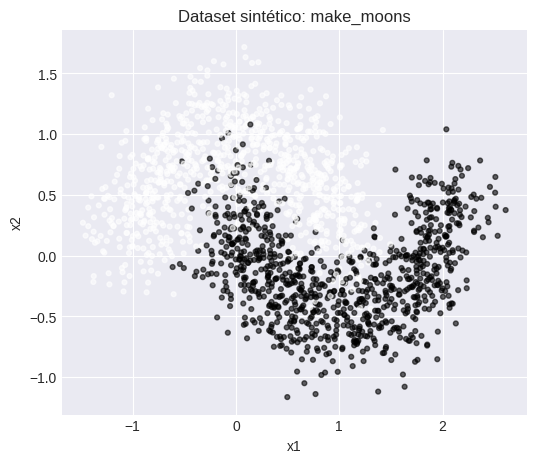

Tamanho treino: 1170 | validação: 630


In [30]:

set_seed(42)

X, y = make_moons(n_samples=1800, noise=0.25, random_state=42)
train_dl, valid_dl, split = make_torch_loaders(X, y, batch_size=64, valid_size=0.35, stratify=True, seed=42)

X_tr, X_va, y_tr, y_va = split

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, s=12, alpha=0.6)
plt.title("Dataset sintético: make_moons")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

print("Tamanho treino:", len(X_tr), "| validação:", len(X_va))

### 2.2 Experimento A — Underfitting
Configuração propositalmente fraca:
- rede pequena
- poucas épocas
- alta regularização (dropout/weight decay)

Esperado:
- treino e validação com desempenho baixo e próximos entre si.

Epoch 001 | train_loss=0.7636 valid_loss=0.7347 | train_acc=0.500 valid_acc=0.500 | gap=+0.000 | grad_mean=3.364e-01
Epoch 010 | train_loss=0.5657 valid_loss=0.5353 | train_acc=0.749 valid_acc=0.844 | gap=-0.096 | grad_mean=2.227e-01
Epoch 020 | train_loss=0.4727 valid_loss=0.4064 | train_acc=0.806 valid_acc=0.863 | gap=-0.058 | grad_mean=1.470e-01
Epoch 030 | train_loss=0.4080 valid_loss=0.3421 | train_acc=0.838 valid_acc=0.871 | gap=-0.034 | grad_mean=1.294e-01
Epoch 040 | train_loss=0.3845 valid_loss=0.3122 | train_acc=0.847 valid_acc=0.875 | gap=-0.028 | grad_mean=1.209e-01


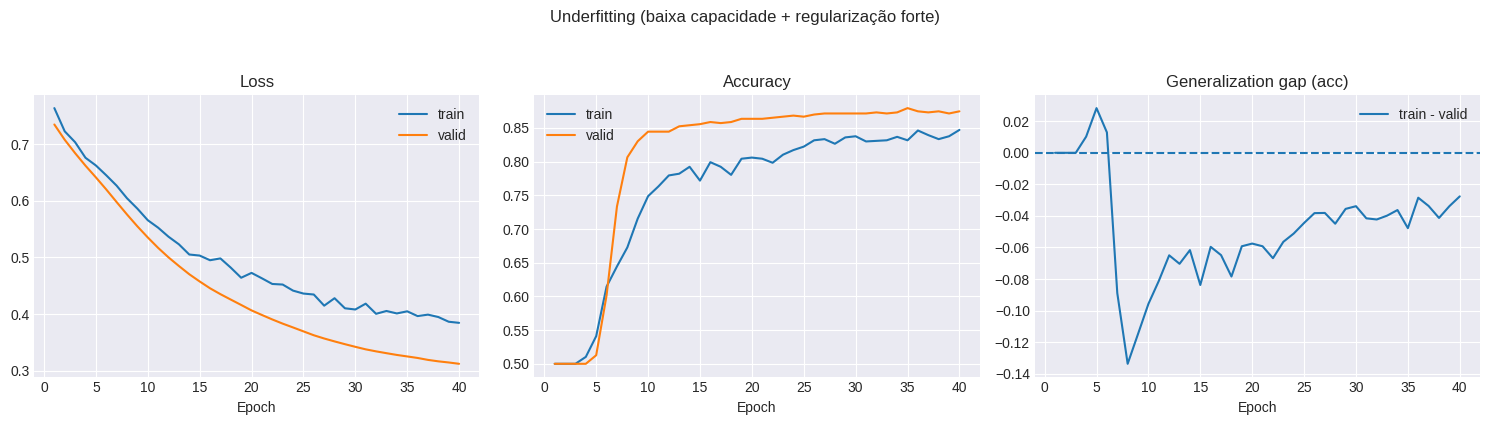

,epoch,train_loss,valid_loss,train_acc,valid_acc,train_f1,valid_f1,train_auc,valid_auc,train_ece,valid_ece,generalization_gap_acc,grad_norm_mean,grad_norm_max
37,38,0.394722,0.316496,0.833333,0.874603,0.831461,0.873600,0.914347,0.954296,0.346591,0.384971,-0.041270,0.126057,0.146086
38,39,0.386404,0.314488,0.837607,0.871429,0.835640,0.870813,0.913421,0.954286,0.336985,0.387023,-0.033822,0.131030,0.183027
39,40,0.384462,0.312153,0.847009,0.874603,0.847139,0.874404,0.916986,0.954306,0.342550,0.385695,-0.027595,0.120943,0.155315


In [31]:

set_seed(42)

model_under = MLPBinary(
    in_dim=2,
    hidden_sizes=[4],   # pequena capacidade
    activation="tanh",
    dropout=0.4,
    batch_norm=False
)

cfg_under = TrainConfig(
    epochs=40,
    lr=2e-3,
    batch_size=64,
    optimizer="adam",
    weight_decay=1e-2,  # regularização forte para o tamanho do problema
    verbose_every=10
)

hist_under = train_model(model_under, train_dl, valid_dl, cfg_under)
plot_train_valid_curves(hist_under, title="Underfitting (baixa capacidade + regularização forte)")
hist_under.tail(3)

### 2.3 Experimento B — Overfitting
Configuração propositalmente com alta capacidade e sem regularização relevante.

Esperado:
- treino melhora muito (loss cai bastante),
- validação para de melhorar (ou piora),
- gap de generalização aumenta.

Epoch 001 | train_loss=0.4310 valid_loss=0.2382 | train_acc=0.802 valid_acc=0.910 | gap=-0.108 | grad_mean=3.800e-01
Epoch 030 | train_loss=0.1498 valid_loss=0.1363 | train_acc=0.938 valid_acc=0.951 | gap=-0.012 | grad_mean=3.570e-01
Epoch 060 | train_loss=0.1476 valid_loss=0.1301 | train_acc=0.938 valid_acc=0.944 | gap=-0.006 | grad_mean=3.523e-01
Epoch 090 | train_loss=0.1479 valid_loss=0.1312 | train_acc=0.938 valid_acc=0.952 | gap=-0.014 | grad_mean=3.436e-01
Epoch 120 | train_loss=0.1334 valid_loss=0.1364 | train_acc=0.938 valid_acc=0.952 | gap=-0.015 | grad_mean=2.787e-01
Epoch 150 | train_loss=0.1389 valid_loss=0.1326 | train_acc=0.941 valid_acc=0.956 | gap=-0.015 | grad_mean=2.905e-01
Epoch 180 | train_loss=0.1278 valid_loss=0.1403 | train_acc=0.942 valid_acc=0.956 | gap=-0.014 | grad_mean=3.124e-01


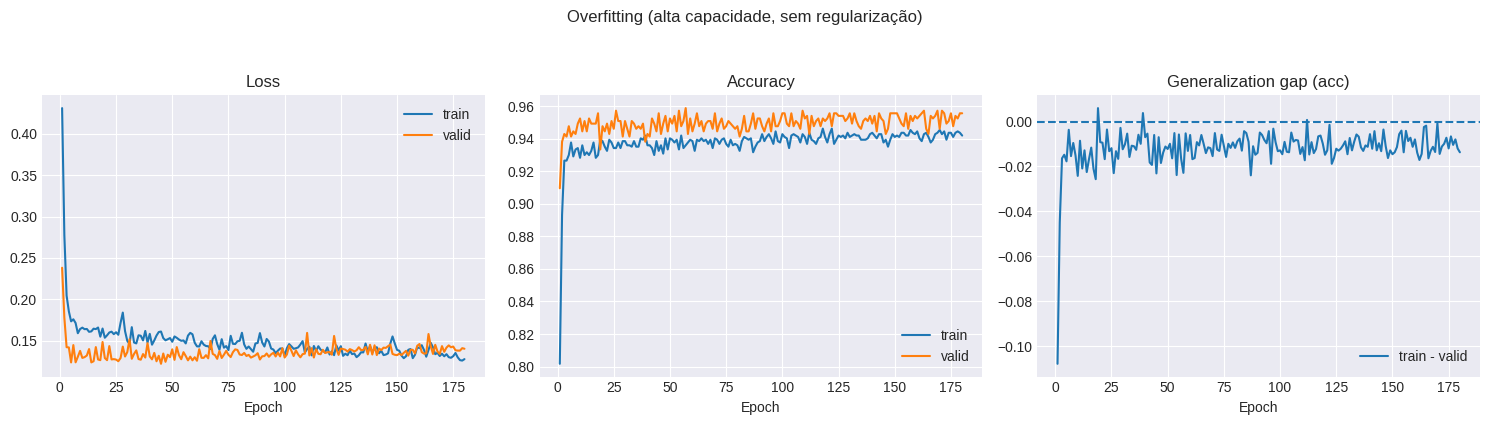

,epoch,train_loss,valid_loss,train_acc,valid_acc,train_f1,valid_f1,train_auc,valid_auc,train_ece,valid_ece,generalization_gap_acc,grad_norm_mean,grad_norm_max
177,178,0.126562,0.138040,0.944444,0.952381,0.944681,0.952381,0.989364,0.989055,0.446865,0.453603,-0.007937,0.269532,0.287506
178,179,0.126003,0.141022,0.943590,0.955556,0.943878,0.955272,0.989457,0.988713,0.454392,0.464291,-0.011966,0.307979,0.401821
179,180,0.127783,0.140312,0.941880,0.955556,0.942275,0.955414,0.989425,0.988975,0.448848,0.461815,-0.013675,0.312440,0.382982


In [32]:

set_seed(42)

model_over = MLPBinary(
    in_dim=2,
    hidden_sizes=[256, 256, 256],  # alta capacidade
    activation="relu",
    dropout=0.0,
    batch_norm=False
)

cfg_over = TrainConfig(
    epochs=180,
    lr=1e-3,
    batch_size=64,
    optimizer="adam",
    weight_decay=0.0,
    verbose_every=30
)

hist_over = train_model(model_over, train_dl, valid_dl, cfg_over)
plot_train_valid_curves(hist_over, title="Overfitting (alta capacidade, sem regularização)")
hist_over.tail(3)

In [33]:
# Visualizando a Complexidade do Modelo

def interactive_overfitting(n_neurons=10, noise_level=0.2, epochs=200):
    # 1. Dados
    X, y = make_moons(n_samples=300, noise=noise_level, random_state=42)
    X_t = torch.FloatTensor(X)
    y_t = torch.FloatTensor(y).unsqueeze(1)

    # 2. Modelo (MLP Simples)
    # Se n_neurons for muito alto (ex: 100), ele vai "overfitar"
    model = nn.Sequential(
        nn.Linear(2, n_neurons),
        nn.ReLU(),
        nn.Linear(n_neurons, n_neurons),
        nn.ReLU(),
        nn.Linear(n_neurons, 1)
    )

    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCEWithLogitsLoss()

    # 3. Treino Rápido
    loss_hist = []
    for _ in range(epochs):
        optimizer.zero_grad()
        out = model(X_t)
        loss = criterion(out, y_t)
        loss.backward()
        optimizer.step()
        loss_hist.append(loss.item())

    # 4. Visualização
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Esquerda: Curva de Loss
    ax[0].plot(loss_hist, color='orange', label='Train Loss')
    ax[0].set_title(f"Convergência (Loss final: {loss_hist[-1]:.4f})")
    ax[0].set_xlabel("Épocas")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    # Direita: Fronteira de Decisão
    plot_decision_boundary(model, X_t, y, ax[1])
    ax[1].set_title(f"Fronteira de Decisão (Neurônios: {n_neurons})")

    plt.tight_layout()
    plt.show()

# Widget Interativo
print("Mova os sliders para ver o Overfitting acontecer ao vivo!")
interact(interactive_overfitting,
         n_neurons=IntSlider(min=2, max=100, step=5, value=10, description='Neurônios'),
         noise_level=FloatSlider(min=0.05, max=0.5, step=0.05, value=0.2, description='Ruído (Noise)'),
         epochs=IntSlider(min=50, max=500, step=50, value=200, description='Épocas'));

Mova os sliders para ver o Overfitting acontecer ao vivo!


interactive(children=(IntSlider(value=10, description='Neurônios', min=2, step=5), FloatSlider(value=0.2, desc…

### 2.4 Experimento C — Ajuste mais equilibrado
Aplicando regularização moderada e capacidade intermediária.

Epoch 001 | train_loss=0.5673 valid_loss=0.4515 | train_acc=0.677 valid_acc=0.859 | gap=-0.182 | grad_mean=8.492e-01
Epoch 030 | train_loss=0.2035 valid_loss=0.1326 | train_acc=0.925 valid_acc=0.948 | gap=-0.023 | grad_mean=2.961e-01
Epoch 060 | train_loss=0.2146 valid_loss=0.1263 | train_acc=0.921 valid_acc=0.956 | gap=-0.035 | grad_mean=3.254e-01
Epoch 090 | train_loss=0.1952 valid_loss=0.1252 | train_acc=0.914 valid_acc=0.949 | gap=-0.036 | grad_mean=2.713e-01
Epoch 120 | train_loss=0.1896 valid_loss=0.1264 | train_acc=0.921 valid_acc=0.949 | gap=-0.029 | grad_mean=2.650e-01


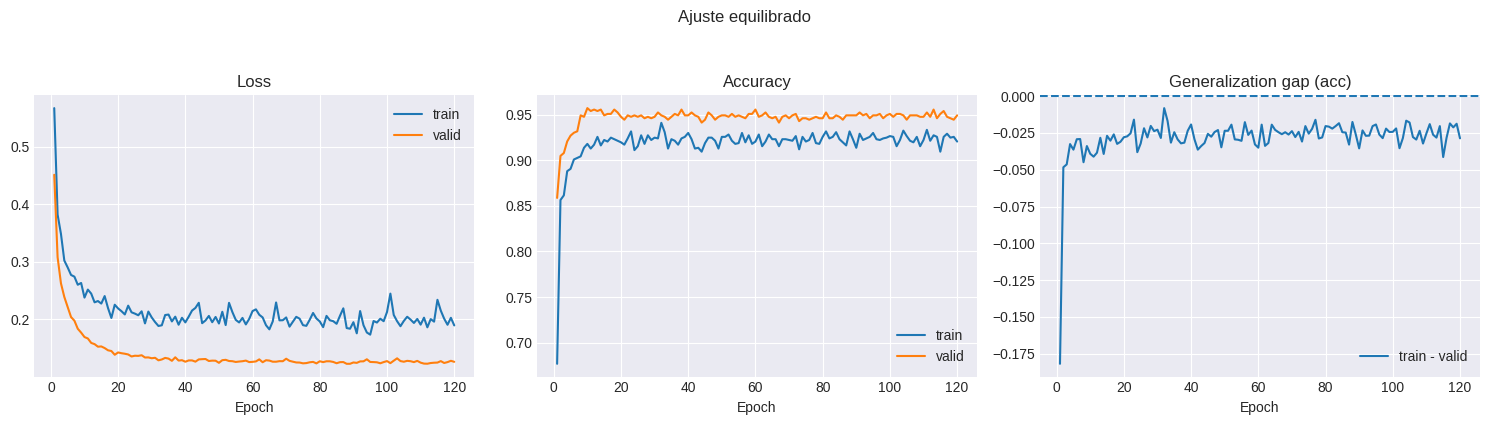

,epoch,train_loss,valid_loss,train_acc,valid_acc,train_f1,valid_f1,train_auc,valid_auc,train_ece,valid_ece,generalization_gap_acc,grad_norm_mean,grad_norm_max
117,118,0.190757,0.125845,0.924786,0.946032,0.925297,0.945860,0.976764,0.992169,0.427605,0.460786,-0.021245,0.266468,0.291539
118,119,0.202856,0.128109,0.925641,0.944444,0.926083,0.944708,0.977617,0.991917,0.429774,0.451914,-0.018803,0.298854,0.740805
119,120,0.189621,0.126361,0.920513,0.949206,0.920034,0.948882,0.977640,0.992089,0.440263,0.459784,-0.028694,0.264996,0.293461


In [34]:

set_seed(42)

model_bal = MLPBinary(
    in_dim=2,
    hidden_sizes=[64, 64],
    activation="relu",
    dropout=0.2,
    batch_norm=True
)

cfg_bal = TrainConfig(
    epochs=120,
    lr=1e-3,
    batch_size=64,
    optimizer="adam",
    weight_decay=1e-4,
    verbose_every=30
)

hist_bal = train_model(model_bal, train_dl, valid_dl, cfg_bal)
plot_train_valid_curves(hist_bal, title="Ajuste equilibrado")
hist_bal.tail(3)

### 2.5 Comparando os regimes (underfit x overfit x equilibrado)

In [35]:

def summarize_history(name, hist_df):
    last = hist_df.iloc[-1]
    best_val_idx = hist_df["valid_acc"].idxmax()
    best = hist_df.loc[best_val_idx]
    return {
        "regime": name,
        "last_train_acc": last["train_acc"],
        "last_valid_acc": last["valid_acc"],
        "last_gap_acc": last["generalization_gap_acc"],
        "best_valid_acc": best["valid_acc"],
        "best_epoch": int(best["epoch"])
    }

summary = pd.DataFrame([
    summarize_history("underfitting", hist_under),
    summarize_history("overfitting", hist_over),
    summarize_history("equilibrado", hist_bal),
])

summary

,regime,last_train_acc,last_valid_acc,last_gap_acc,best_valid_acc,best_epoch
0,underfitting,0.847009,0.874603,-0.027595,0.879365,35
1,overfitting,0.941880,0.955556,-0.013675,0.958730,57
2,equilibrado,0.920513,0.949206,-0.028694,0.957143,10


**Leitura didática rápida**  
- **Underfitting**: baixo desempenho em treino e validação, gap pequeno.  
- **Overfitting**: treino alto, validação estagna/piora, gap cresce.  
- **Equilibrado**: melhor compromisso entre capacidade e generalização.

---
## 3) Gap de generalização e viés–variância

### Conceitos práticos
- **Gap de generalização**: `métrica_treino - métrica_validação` (por ex., acurácia).  
  Gap alto sugere overfitting.
- **Viés alto**: modelo incapaz de representar o padrão (underfitting).
- **Variância alta**: modelo muito sensível ao conjunto de treino (overfitting).

A seguir, medimos variação entre diferentes seeds para ter um sinal simples de variância.

In [36]:

def run_regime(seed, regime="under"):
    set_seed(seed)
    X, y = make_moons(n_samples=1500, noise=0.28, random_state=seed)
    train_dl, valid_dl, _ = make_torch_loaders(X, y, batch_size=64, valid_size=0.35, stratify=True, seed=seed)

    if regime == "under":
        model = MLPBinary(2, [4], activation="tanh", dropout=0.4, batch_norm=False)
        cfg = TrainConfig(epochs=40, lr=2e-3, optimizer="adam", weight_decay=1e-2, verbose_every=9999)
    elif regime == "over":
        model = MLPBinary(2, [256,256,256], activation="relu", dropout=0.0, batch_norm=False)
        cfg = TrainConfig(epochs=120, lr=1e-3, optimizer="adam", weight_decay=0.0, verbose_every=9999)
    else:
        model = MLPBinary(2, [64,64], activation="relu", dropout=0.2, batch_norm=True)
        cfg = TrainConfig(epochs=100, lr=1e-3, optimizer="adam", weight_decay=1e-4, verbose_every=9999)

    hist = train_model(model, train_dl, valid_dl, cfg)
    best_val = hist["valid_acc"].max()
    best_gap = hist.loc[hist["valid_acc"].idxmax(), "generalization_gap_acc"]
    return best_val, best_gap

rows = []
for regime in ["under", "over", "balanced"]:
    for seed in [1, 7, 21, 42, 99]:
        bval, bgap = run_regime(seed, regime=regime)
        rows.append({"regime": regime, "seed": seed, "best_valid_acc": bval, "gap_at_best": bgap})

df_var = pd.DataFrame(rows)
df_var.groupby("regime").agg(
    mean_best_valid_acc=("best_valid_acc","mean"),
    std_best_valid_acc=("best_valid_acc","std"),
    mean_gap=("gap_at_best","mean")
).reset_index()

Epoch 001 | train_loss=0.6405 valid_loss=0.6185 | train_acc=0.735 valid_acc=0.815 | gap=-0.080 | grad_mean=2.437e-01
Epoch 040 | train_loss=0.3701 valid_loss=0.3115 | train_acc=0.859 valid_acc=0.876 | gap=-0.017 | grad_mean=1.261e-01
Epoch 001 | train_loss=0.6866 valid_loss=0.6797 | train_acc=0.559 valid_acc=0.533 | gap=+0.026 | grad_mean=2.120e-01
Epoch 040 | train_loss=0.3574 valid_loss=0.3898 | train_acc=0.852 valid_acc=0.832 | gap=+0.020 | grad_mean=1.364e-01
Epoch 001 | train_loss=0.7309 valid_loss=0.7062 | train_acc=0.499 valid_acc=0.501 | gap=-0.001 | grad_mean=2.776e-01
Epoch 040 | train_loss=0.3561 valid_loss=0.3772 | train_acc=0.850 valid_acc=0.846 | gap=+0.005 | grad_mean=1.334e-01
Epoch 001 | train_loss=0.7636 valid_loss=0.7345 | train_acc=0.501 valid_acc=0.499 | gap=+0.001 | grad_mean=3.587e-01
Epoch 040 | train_loss=0.3858 valid_loss=0.3414 | train_acc=0.843 valid_acc=0.869 | gap=-0.025 | grad_mean=1.483e-01
Epoch 001 | train_loss=0.7004 valid_loss=0.6813 | train_acc=0.57

,regime,mean_best_valid_acc,std_best_valid_acc,mean_gap
0,balanced,0.932952,0.010975,-0.020337
1,over,0.933714,0.010293,-0.006125
2,under,0.859048,0.018418,-0.022945


**Interpretação**  
- `mean_best_valid_acc` baixo em underfitting costuma indicar **viés alto**.  
- `std_best_valid_acc` alto em overfitting costuma indicar **variância alta** (sensibilidade à amostragem/seed).  
- `mean_gap` maior reforça o diagnóstico de baixa generalização.

---
## 4) Métricas além de acurácia: F1, AUC e calibration (ECE)

Para evidenciar limitações da acurácia, vamos criar um dataset **desbalanceado**.

In [37]:

set_seed(123)

X_imb, y_imb = make_classification(
    n_samples=3000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_clusters_per_class=2,
    weights=[0.90, 0.10],  # forte desbalanceamento
    class_sep=1.0,
    random_state=123
)

train_dl_imb, valid_dl_imb, split_imb = make_torch_loaders(
    X_imb, y_imb, batch_size=128, valid_size=0.30, stratify=True, seed=123
)

X_tr_imb, X_va_imb, y_tr_imb, y_va_imb = split_imb
print("Treino classe positiva (%):", y_tr_imb.mean()*100)
print("Val classe positiva (%):", y_va_imb.mean()*100)

Treino classe positiva (%): 10.428571428571429
Val classe positiva (%): 10.444444444444445


Epoch 001 | train_loss=0.7125 valid_loss=0.5593 | train_acc=0.495 valid_acc=0.879 | gap=-0.384 | grad_mean=1.422e+00
Epoch 020 | train_loss=0.1057 valid_loss=0.1159 | train_acc=0.966 valid_acc=0.963 | gap=+0.003 | grad_mean=2.946e-01
Epoch 040 | train_loss=0.0731 valid_loss=0.1067 | train_acc=0.979 valid_acc=0.968 | gap=+0.011 | grad_mean=3.583e-01
Epoch 060 | train_loss=0.0486 valid_loss=0.1174 | train_acc=0.984 valid_acc=0.970 | gap=+0.014 | grad_mean=3.686e-01
Epoch 080 | train_loss=0.0375 valid_loss=0.1228 | train_acc=0.986 valid_acc=0.966 | gap=+0.021 | grad_mean=3.883e-01


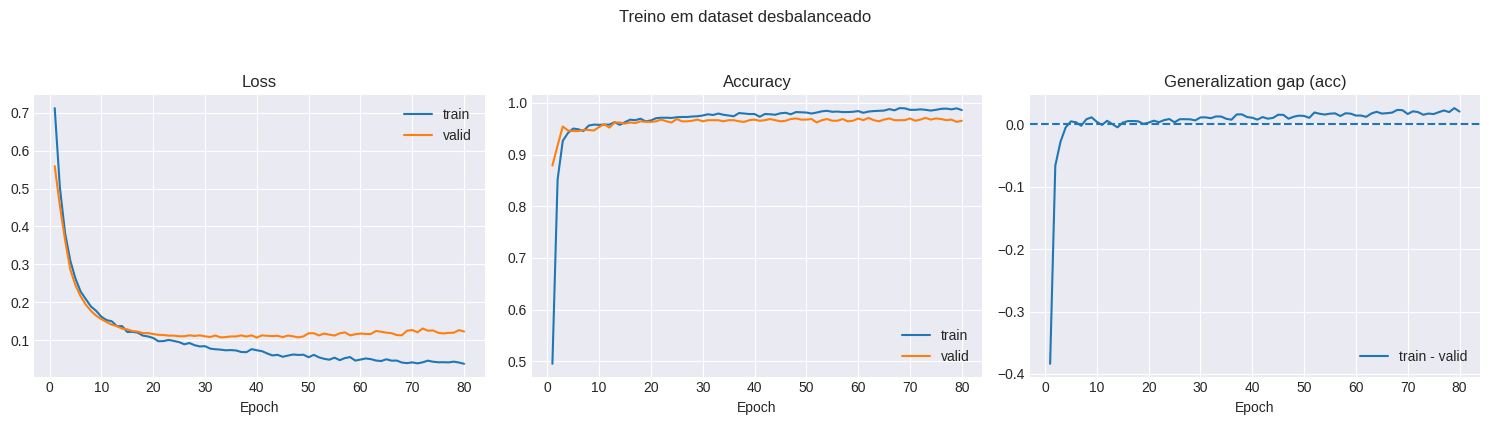

In [38]:

set_seed(123)

model_imb = MLPBinary(
    in_dim=X_imb.shape[1],
    hidden_sizes=[128, 64],
    activation="relu",
    dropout=0.2,
    batch_norm=True
)

cfg_imb = TrainConfig(
    epochs=80,
    lr=1e-3,
    batch_size=128,
    optimizer="adam",
    weight_decay=1e-4,
    verbose_every=20
)

hist_imb = train_model(model_imb, train_dl_imb, valid_dl_imb, cfg_imb)
plot_train_valid_curves(hist_imb, "Treino em dataset desbalanceado")

In [39]:

# Avaliação final detalhada
loss_fn = nn.BCEWithLogitsLoss()
val_loss, val_metrics, y_true, y_prob = evaluate_model(model_imb, valid_dl_imb, loss_fn)

print("Métricas de validação (threshold=0.5):")
for k, v in val_metrics.items():
    print(f"{k:>8}: {v:.4f}")

Métricas de validação (threshold=0.5):
accuracy: 0.9656
      f1: 0.8121
     auc: 0.9488
   brier: 0.0273
     ece: 0.8799


In [40]:
# Calibração e Reliability Diagram

def calibration_lab(regularization_strength=0.0):
    # 1. Gerar dados e dividir
    X, y = make_moons(n_samples=1000, noise=0.3, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
    X_test_t = torch.FloatTensor(X_test)

    # 2. Modelo propenso a Overconfidence (pouca regularização se strength=0)
    model = nn.Sequential(
        nn.Linear(2, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    )

    # Weight decay atua como regularizador
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=regularization_strength)
    criterion = nn.BCEWithLogitsLoss()

    # Treino longo para forçar confiança alta
    for _ in range(300):
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

    # 3. Avaliação
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_test_t)).numpy().flatten()

    # Curva de Calibração
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma de Confiança
    ax[0].hist(probs, range=(0, 1), bins=10, histtype="step", lw=2)
    ax[0].set_xlabel("Confiança da Previsão")
    ax[0].set_ylabel("Contagem")
    ax[0].set_title("Histograma de Confiança do Modelo")

    # Reliability Diagram
    ax[1].plot([0, 1], [0, 1], "k:", label="Perfeitamente Calibrado")
    ax[1].plot(prob_pred, prob_true, "s-", label="Seu Modelo")
    ax[1].set_ylabel("Fração de Positivos (Real)")
    ax[1].set_xlabel("Confiança Média Prevista")
    ax[1].set_title("Reliability Diagram")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

print("Aumente a Regularização (Weight Decay) para melhorar a calibração")
print("Sem regularização (0.0), o modelo tende a ser 'Arrogante' (curva abaixo da diagonal em alta confiança).")
interact(calibration_lab,
         regularization_strength=Dropdown(options=[('0.0 (Overconfident)', 0.0), ('0.01 (Better)', 0.01), ('0.1 (Underfit)', 0.1)], description='Reg (L2)'));

Aumente a Regularização (Weight Decay) para melhorar a calibração
Sem regularização (0.0), o modelo tende a ser 'Arrogante' (curva abaixo da diagonal em alta confiança).


interactive(children=(Dropdown(description='Reg (L2)', options=(('0.0 (Overconfident)', 0.0), ('0.01 (Better)'…

### Por que isso importa?
- **Acurácia** pode ficar “alta” só por acertar a classe majoritária.
- **F1** considera equilíbrio entre precisão e recall na classe positiva.
- **AUC** avalia ordenação de probabilidades independentemente de um threshold fixo.
- **ECE** mede calibração: se probabilidades previstas condizem com frequências reais.

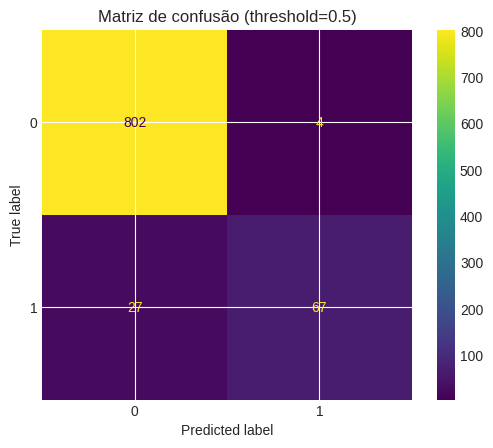

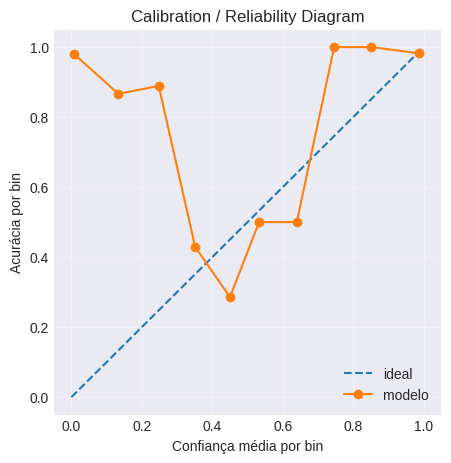

In [41]:

# Matriz de confusão para visualizar erros por classe
y_pred = (y_prob >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Matriz de confusão (threshold=0.5)")
plt.show()

# Reliability diagram (calibração)
reliability_diagram(y_true, y_prob, n_bins=10, title="Calibration / Reliability Diagram")

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confidence_histogram(y_prob, n_bins=10, title="Histograma de confiança por bin"):
    y_prob = np.asarray(y_prob).ravel()
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    counts, _ = np.histogram(y_prob, bins=bins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    width = (bins[1] - bins[0]) * 0.9

    plt.figure(figsize=(7, 4))
    plt.bar(bin_centers, counts, width=width, edgecolor="black")
    plt.xlabel("Confiança / Probabilidade prevista")
    plt.ylabel("Nº de amostras")
    plt.title(title)
    plt.xticks(bins)
    plt.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.show()

    return bins, counts


def plot_confidence_histogram_correct_incorrect(y_true, y_prob, n_bins=10,
                                                threshold=0.5,
                                                title="Histograma por bin (acertos vs erros)"):
    y_true = np.asarray(y_true).ravel().astype(int)
    y_prob = np.asarray(y_prob).ravel()

    # Predição binária (para separar acerto/erro)
    y_pred = (y_prob >= threshold).astype(int)
    correct = (y_pred == y_true)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_idx = np.digitize(y_prob, bins) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    counts_total = np.bincount(bin_idx, minlength=n_bins)
    counts_correct = np.bincount(bin_idx[correct], minlength=n_bins)
    counts_incorrect = counts_total - counts_correct

    bin_centers = (bins[:-1] + bins[1:]) / 2
    width = (bins[1] - bins[0]) * 0.9

    plt.figure(figsize=(7, 4))
    plt.bar(bin_centers, counts_correct, width=width, edgecolor="black", label="Acertos")
    plt.bar(bin_centers, counts_incorrect, width=width, bottom=counts_correct,
            edgecolor="black", label="Erros")
    plt.xlabel("Confiança / Probabilidade prevista")
    plt.ylabel("Nº de amostras")
    plt.title(title)
    plt.xticks(bins)
    plt.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.legend()
    plt.show()

    return bins, counts_total, counts_correct, counts_incorrect

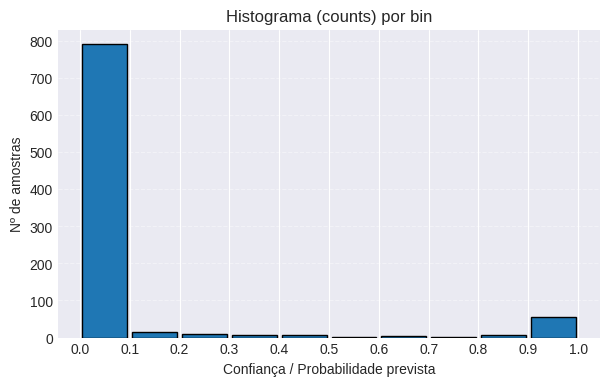

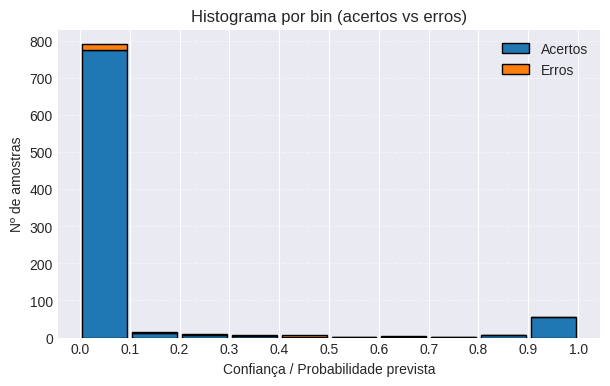

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 array([791,  15,   9,   7,   7,   2,   4,   2,   7,  56]),
 array([776,  13,   8,   3,   2,   1,   2,   2,   7,  55]),
 array([15,  2,  1,  4,  5,  1,  2,  0,  0,  1]))

In [43]:
plot_confidence_histogram(y_prob, n_bins=10, title="Histograma (counts) por bin")

# Versão mais informativa (acertos vs erros)
plot_confidence_histogram_correct_incorrect(y_true, y_prob, n_bins=10, threshold=0.5)

---
## 5) Sinais de instabilidade: exploding/vanishing gradients e loss oscilando

### 5.1 Caso instável (exploding + loss oscilando)
Vamos induzir instabilidade com:
- rede relativamente profunda,
- `SGD` com taxa de aprendizado excessiva.

In [47]:

set_seed(202)

X_bad, y_bad = make_moons(n_samples=2000, noise=0.30, random_state=202)
train_dl_bad, valid_dl_bad, _ = make_torch_loaders(X_bad, y_bad, batch_size=128, valid_size=0.35, stratify=True, seed=202)

model_bad = MLPBinary(
    in_dim=2,
    hidden_sizes=[128, 128, 128, 128, 128],
    activation="relu",
    dropout=0.0,
    batch_norm=False
)

cfg_bad = TrainConfig(
    epochs=60,
    lr=1.0,                 # intencionalmente alto
    batch_size=128,
    optimizer="sgd",
    momentum=0.9,
    weight_decay=0.0,
    grad_clip=None,
    #grad_clip=1.0,    # <--- Corta gradientes gigantes (contorno pra evitar o NaN)
    verbose_every=10
)

# O que vocês podem testar
## 1. Clip muito agressivo (Treino lento, mas seguro)
#cfg_safe = TrainConfig(..., lr=1.0, grad_clip=0.1)
#
## 2. Clip padrão (Equilíbrio)
#cfg_standard = TrainConfig(..., lr=1.0, grad_clip=1.0)
#
## 3. Clip muito solto (Risco de explosão/NaN voltar)
#cfg_loose = TrainConfig(..., lr=1.0, grad_clip=50.0)


hist_bad = train_model(model_bad, train_dl_bad, valid_dl_bad, cfg_bad)

Epoch 001 | train_loss=0.7705 valid_loss=1.0516 | train_acc=0.707 valid_acc=0.500 | gap=+0.207 | grad_mean=7.199e-01
Epoch 010 | train_loss=1.0653 valid_loss=0.6630 | train_acc=0.711 valid_acc=0.500 | gap=+0.211 | grad_mean=2.082e+00


ValueError: Input contains NaN.

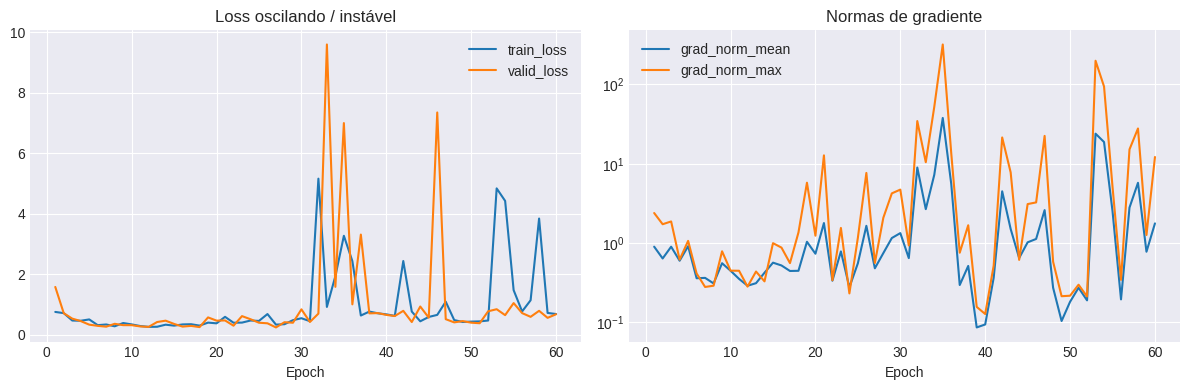

In [46]:

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(hist_bad["epoch"], hist_bad["train_loss"], label="train_loss")
axes[0].plot(hist_bad["epoch"], hist_bad["valid_loss"], label="valid_loss")
axes[0].set_title("Loss oscilando / instável")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist_bad["epoch"], hist_bad["grad_norm_mean"], label="grad_norm_mean")
axes[1].plot(hist_bad["epoch"], hist_bad["grad_norm_max"], label="grad_norm_max")
axes[1].set_title("Normas de gradiente")
axes[1].set_xlabel("Epoch")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.2 Estabilizando o treino (reduzir LR + gradient clipping + batch norm)

In [48]:

set_seed(202)

model_fix = MLPBinary(
    in_dim=2,
    hidden_sizes=[128, 128, 128, 128, 128],
    activation="relu",
    dropout=0.1,
    batch_norm=True
)

cfg_fix = TrainConfig(
    epochs=60,
    lr=0.03,                # LR bem menor
    batch_size=128,
    optimizer="sgd",
    momentum=0.9,
    weight_decay=1e-4,
    grad_clip=1.0,          # clipping
    verbose_every=10
)

hist_fix = train_model(model_fix, train_dl_bad, valid_dl_bad, cfg_fix)

Epoch 001 | train_loss=0.5161 valid_loss=0.6176 | train_acc=0.759 valid_acc=0.871 | gap=-0.112 | grad_mean=1.256e+00
Epoch 010 | train_loss=0.2340 valid_loss=0.2210 | train_acc=0.906 valid_acc=0.929 | gap=-0.022 | grad_mean=5.627e-01
Epoch 020 | train_loss=0.2484 valid_loss=0.2159 | train_acc=0.894 valid_acc=0.919 | gap=-0.025 | grad_mean=5.721e-01
Epoch 030 | train_loss=0.2224 valid_loss=0.2167 | train_acc=0.912 valid_acc=0.927 | gap=-0.016 | grad_mean=4.133e-01
Epoch 040 | train_loss=0.2034 valid_loss=0.2161 | train_acc=0.916 valid_acc=0.921 | gap=-0.005 | grad_mean=3.456e-01
Epoch 050 | train_loss=0.2208 valid_loss=0.2220 | train_acc=0.916 valid_acc=0.924 | gap=-0.008 | grad_mean=3.828e-01
Epoch 060 | train_loss=0.2329 valid_loss=0.2165 | train_acc=0.914 valid_acc=0.926 | gap=-0.012 | grad_mean=3.717e-01


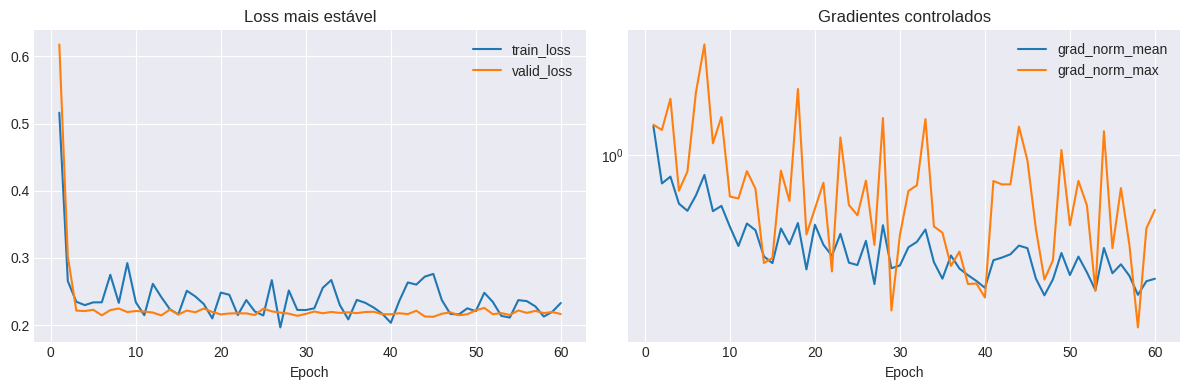

In [49]:

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(hist_fix["epoch"], hist_fix["train_loss"], label="train_loss")
axes[0].plot(hist_fix["epoch"], hist_fix["valid_loss"], label="valid_loss")
axes[0].set_title("Loss mais estável")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist_fix["epoch"], hist_fix["grad_norm_mean"], label="grad_norm_mean")
axes[1].plot(hist_fix["epoch"], hist_fix["grad_norm_max"], label="grad_norm_max")
axes[1].set_title("Gradientes controlados")
axes[1].set_xlabel("Epoch")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.3 Exemplo de vanishing gradients (sigmoid + rede profunda)
A combinação de muitas camadas com ativações saturantes pode reduzir gradientes em camadas iniciais.

In [50]:

set_seed(77)

X_van, y_van = make_moons(n_samples=1800, noise=0.28, random_state=77)
train_dl_van, valid_dl_van, _ = make_torch_loaders(X_van, y_van, batch_size=128, valid_size=0.35, stratify=True, seed=77)

# Rede mais profunda com sigmoid (saturante)
model_van = MLPBinary(
    in_dim=2,
    hidden_sizes=[64,64,64,64,64,64],
    activation="sigmoid",
    dropout=0.0,
    batch_norm=False
).to(device)

opt = torch.optim.SGD(model_van.parameters(), lr=0.05)
loss_fn = nn.BCEWithLogitsLoss()

layer_grad_history = []

for epoch in range(1, 31):
    model_van.train()
    grads_epoch = []

    for xb, yb in train_dl_van:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model_van(xb), yb)
        loss.backward()

        # Coleta norma dos gradientes por camada Linear
        layer_norms = []
        for m in model_van.modules():
            if isinstance(m, nn.Linear) and m.weight.grad is not None:
                layer_norms.append(m.weight.grad.data.norm(2).item())
        grads_epoch.append(layer_norms)

        opt.step()

    # média por camada ao longo dos batches
    layer_grad_history.append(np.mean(np.array(grads_epoch), axis=0))

layer_grad_history = np.array(layer_grad_history)
print("Formato [epochs, n_linear_layers]:", layer_grad_history.shape)

Formato [epochs, n_linear_layers]: (30, 7)


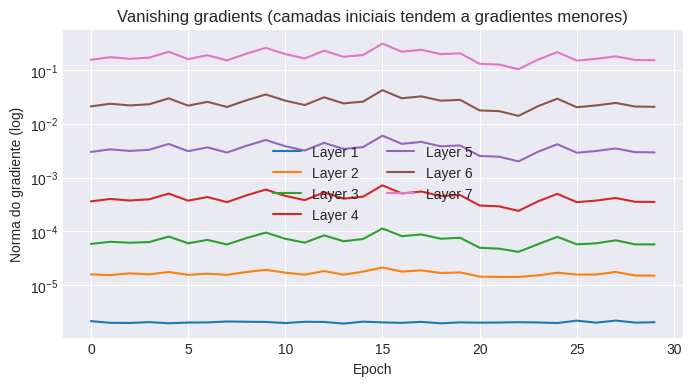

In [51]:

plt.figure(figsize=(8,4))
for i in range(layer_grad_history.shape[1]):
    plt.plot(layer_grad_history[:, i], label=f"Layer {i+1}")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Norma do gradiente (log)")
plt.title("Vanishing gradients (camadas iniciais tendem a gradientes menores)")
plt.legend(ncol=2)
plt.show()

**Discussão:**  
- Se gradientes das primeiras camadas ficam persistentemente muito baixos, o backbone “não aprende”.
- Mitigações comuns: inicialização adequada, ativações como ReLU/GELU, normalização, conexões residuais.

In [52]:
# Diagnóstico de Gradientes (Vanishing Lab)

import torch.nn.init as init

def train_deep_net(activation_name, n_layers=10):
    # Dados simples
    X = torch.randn(100, 10)
    y = torch.randint(0, 2, (100, 1)).float()

    layers = []
    input_dim = 10

    # Dicionário mapeando nome -> objeto da classe
    act_dict = {
        'Sigmoid (Problemático)': nn.Sigmoid(),
        'ReLU (Estável)': nn.ReLU(),
        'Tanh': nn.Tanh()
    }
    activation_fn = act_dict[activation_name]

    for i in range(n_layers):
        layer = nn.Linear(input_dim, 10)

        # --- O SEGREDO ESTÁ AQUI: Inicialização Correta ---
        # Se não inicializar corretamente, a ReLU também falha em profundidade.
        if 'ReLU' in activation_name:
            # He Initialization (Otimizada para ReLU)
            init.kaiming_normal_(layer.weight, nonlinearity='relu')
        else:
            # Xavier Initialization (Otimizada para Sigmoid/Tanh)
            init.xavier_normal_(layer.weight)

        layers.append(layer)
        layers.append(activation_fn)
        input_dim = 10

    layers.append(nn.Linear(10, 1))

    model = nn.Sequential(*layers)
    criterion = nn.BCEWithLogitsLoss()
    out = model(X)
    loss = criterion(out, y)
    loss.backward()

    # Extraindo magnitude
    grads = []
    layer_idx = []

    for i, (name, param) in enumerate(model.named_parameters()):
        if 'weight' in name and param.grad is not None:
            grads.append(param.grad.abs().mean().item())
            layer_idx.append(i//2 + 1)

    return layer_idx, grads

def visualize_gradients(activation='Sigmoid (Problemático)', n_layers=15):
    layers, grads = train_deep_net(activation, n_layers)

    plt.figure(figsize=(10, 6))

    # Plot principal
    plt.plot(layers, grads, marker='o', linewidth=2, linestyle='-', label='Gradiente Médio')

    # Linha de perigo (Limiar visual)
    plt.axhline(y=1e-5, color='r', linestyle='--', alpha=0.3, label='Zona de Perigo (Vanishing)')

    plt.title(f"Fluxo de Gradientes com Inicialização Correta\n({activation} - {n_layers} Camadas)")
    plt.xlabel("Índice da Camada (1 = Entrada ... N = Saída)")
    plt.ylabel("Magnitude Média do Gradiente (Log Scale)")
    plt.yscale('log')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)

    # Lógica de Detecção Ajustada
    # Vanishing severo: gradiente da entrada é < 1e-5
    first_layer_grad = grads[0]
    last_layer_grad = grads[-1]

    if first_layer_grad < 1e-5:
        plt.text(len(layers)/2, first_layer_grad, "VANISHING CONFIRMADO!", fontsize=14, color='red', ha='center', fontweight='bold')
    elif first_layer_grad < (last_layer_grad / 100):
        # Se o gradiente caiu 100x da saída para a entrada, também é um alerta
        plt.text(len(layers)/2, min(grads), "Degradação de Sinal", fontsize=12, color='orange', ha='center')
    else:
        plt.text(len(layers)/2, min(grads), "FLUXO SAUDÁVEL", fontsize=14, color='green', ha='center', fontweight='bold')

    plt.show()

print("🔽 Agora com Inicialização correta (Kaiming/Xavier). A ReLU deve aguentar muito mais! 🔽")
interact(visualize_gradients,
         activation=Dropdown(options=['Sigmoid (Problemático)', 'ReLU (Estável)', 'Tanh'], value='Sigmoid (Problemático)'),
         n_layers=IntSlider(min=1, max=50, step=5, value=15, description='Profundidade'));

🔽 Agora com Inicialização correta (Kaiming/Xavier). A ReLU deve aguentar muito mais! 🔽


interactive(children=(Dropdown(description='activation', options=('Sigmoid (Problemático)', 'ReLU (Estável)', …

---
## 6) Checklist de diagnóstico (para levar para produção)

1. **Curvas**: acompanhar `train` vs `valid` (loss e métrica-alvo).  
2. **Gap**: monitorar gap de generalização por época.  
3. **Métricas certas**: usar F1/AUC/calibração quando acurácia for insuficiente.  
4. **Estabilidade numérica**: observar gradientes, NaNs e oscilação abrupta da loss.  
5. **Ações corretivas rápidas**:  
   - reduzir LR  
   - aplicar clipping  
   - rever capacidade/regularização  
   - usar batch norm / normalização dos dados.

## 7) Exercícios sugeridos

1. Reproduza overfitting e aplique **early stopping**.  
2. Compare `Adam` vs `SGD+momentum` no mesmo dataset e discuta estabilidade.  
3. Em dataset desbalanceado, ajuste threshold para maximizar F1.  
4. Projete um experimento para reduzir ECE sem perder AUC.

---
## 8) Soluções dos Exercícios

### Exercício 1: Reproduzir overfitting e aplicar Early Stopping

In [ ]:
# Exercício 1: Implementar Early Stopping para evitar overfitting

class EarlyStopping:
    """
    Early Stopping para parar o treino quando a métrica de validação não melhorar.
    
    Args:
        patience: número de épocas sem melhoria antes de parar
        min_delta: mudança mínima para considerar como melhoria
        mode: 'min' para loss (queremos minimizar) ou 'max' para acurácia (queremos maximizar)
    """
    def __init__(self, patience=10, min_delta=0.001, mode='min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_value = None
        self.early_stop = False
        self.best_epoch = 0
        
    def __call__(self, current_value, epoch):
        if self.best_value is None:
            self.best_value = current_value
            self.best_epoch = epoch
        elif self._is_improvement(current_value):
            self.best_value = current_value
            self.best_epoch = epoch
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                
    def _is_improvement(self, current_value):
        if self.mode == 'min':
            return current_value < (self.best_value - self.min_delta)
        else:  # mode == 'max'
            return current_value > (self.best_value + self.min_delta)

def train_model_with_early_stopping(
    model: nn.Module,
    train_dl: DataLoader,
    valid_dl: DataLoader,
    cfg: TrainConfig,
    patience: int = 15,
    min_delta: float = 0.001
):
    """
    Versão modificada do train_model com early stopping.
    """
    model.to(device)
    loss_fn = nn.BCEWithLogitsLoss()
    opt = get_optimizer(model, cfg)
    
    early_stopping = EarlyStopping(patience=patience, min_delta=min_delta, mode='min')
    
    history = {
        "epoch": [],
        "train_loss": [], "valid_loss": [],
        "train_acc": [], "valid_acc": [],
        "generalization_gap_acc": [],
    }
    
    best_model_state = None
    
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        batch_losses = []
        y_prob_train, y_true_train = [], []
        
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            
            batch_losses.append(loss.item())
            y_prob_train.append(torch.sigmoid(logits).detach().cpu().numpy().ravel())
            y_true_train.append(yb.detach().cpu().numpy().ravel())
        
        y_prob_train = np.concatenate(y_prob_train)
        y_true_train = np.concatenate(y_true_train).astype(int)
        train_acc = accuracy_score(y_true_train, (y_prob_train >= 0.5).astype(int))
        
        valid_loss, valid_metrics, _, _ = evaluate_model(model, valid_dl, loss_fn)
        
        history["epoch"].append(epoch)
        history["train_loss"].append(float(np.mean(batch_losses)))
        history["valid_loss"].append(valid_loss)
        history["train_acc"].append(train_acc)
        history["valid_acc"].append(valid_metrics["accuracy"])
        history["generalization_gap_acc"].append(train_acc - valid_metrics["accuracy"])
        
        # Salvar melhor modelo
        if early_stopping.best_value is None or valid_loss < early_stopping.best_value:
            best_model_state = model.state_dict().copy()
        
        # Checar early stopping
        early_stopping(valid_loss, epoch)
        
        if (epoch % cfg.verbose_every == 0) or (epoch == 1):
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={history['train_loss'][-1]:.4f} valid_loss={valid_loss:.4f} | "
                f"train_acc={history['train_acc'][-1]:.3f} valid_acc={history['valid_acc'][-1]:.3f} | "
                f"patience_counter={early_stopping.counter}/{patience}"
            )
        
        if early_stopping.early_stop:
            print(f"\n⚠️ Early stopping acionado na época {epoch}!")
            print(f"✅ Melhor modelo foi na época {early_stopping.best_epoch} com valid_loss={early_stopping.best_value:.4f}")
            break
    
    # Restaurar melhor modelo
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"🔄 Modelo restaurado para a melhor época ({early_stopping.best_epoch})")
    
    return pd.DataFrame(history), early_stopping.best_epoch

In [ ]:
# Testando Early Stopping: comparar modelo COM e SEM early stopping

set_seed(42)
X, y = make_moons(n_samples=1500, noise=0.25, random_state=42)
train_dl, valid_dl, _ = make_torch_loaders(X, y, batch_size=64, valid_size=0.35, stratify=True, seed=42)

# Modelo propenso a overfitting (sem regularização)
print("=" * 60)
print("TREINAMENTO SEM EARLY STOPPING (vai overfitar)")
print("=" * 60)

set_seed(42)
model_no_es = MLPBinary(
    in_dim=2,
    hidden_sizes=[128, 128, 64],
    activation="relu",
    dropout=0.0,
    batch_norm=False
)

cfg_no_es = TrainConfig(
    epochs=200,
    lr=1e-3,
    batch_size=64,
    optimizer="adam",
    weight_decay=0.0,
    verbose_every=40
)

hist_no_es = train_model(model_no_es, train_dl, valid_dl, cfg_no_es)

print("\n" + "=" * 60)
print("TREINAMENTO COM EARLY STOPPING")
print("=" * 60)

set_seed(42)
model_with_es = MLPBinary(
    in_dim=2,
    hidden_sizes=[128, 128, 64],
    activation="relu",
    dropout=0.0,
    batch_norm=False
)

cfg_with_es = TrainConfig(
    epochs=200,
    lr=1e-3,
    batch_size=64,
    optimizer="adam",
    weight_decay=0.0,
    verbose_every=20
)

hist_with_es, best_epoch = train_model_with_early_stopping(
    model_with_es, train_dl, valid_dl, cfg_with_es, 
    patience=20, 
    min_delta=0.001
)

In [ ]:
# Comparação visual: Early Stopping vs Sem Early Stopping

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sem Early Stopping
axes[0, 0].plot(hist_no_es["epoch"], hist_no_es["train_loss"], label="train", linewidth=2)
axes[0, 0].plot(hist_no_es["epoch"], hist_no_es["valid_loss"], label="valid", linewidth=2)
axes[0, 0].set_title("SEM Early Stopping - Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(hist_no_es["epoch"], hist_no_es["train_acc"], label="train", linewidth=2)
axes[0, 1].plot(hist_no_es["epoch"], hist_no_es["valid_acc"], label="valid", linewidth=2)
axes[0, 1].set_title("SEM Early Stopping - Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Com Early Stopping
axes[1, 0].plot(hist_with_es["epoch"], hist_with_es["train_loss"], label="train", linewidth=2)
axes[1, 0].plot(hist_with_es["epoch"], hist_with_es["valid_loss"], label="valid", linewidth=2)
axes[1, 0].axvline(best_epoch, color='red', linestyle='--', label=f'Parada (epoch {best_epoch})', linewidth=2)
axes[1, 0].set_title("COM Early Stopping - Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(hist_with_es["epoch"], hist_with_es["train_acc"], label="train", linewidth=2)
axes[1, 1].plot(hist_with_es["epoch"], hist_with_es["valid_acc"], label="valid", linewidth=2)
axes[1, 1].axvline(best_epoch, color='red', linestyle='--', label=f'Parada (epoch {best_epoch})', linewidth=2)
axes[1, 1].set_title("COM Early Stopping - Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Comparação numérica
print("\n📊 COMPARAÇÃO FINAL:")
print("=" * 60)
print(f"{'Métrica':<30} {'Sem ES':>12} {'Com ES':>12}")
print("=" * 60)
print(f"{'Melhor Valid Accuracy':<30} {hist_no_es['valid_acc'].max():>12.4f} {hist_with_es['valid_acc'].max():>12.4f}")
print(f"{'Última Valid Accuracy':<30} {hist_no_es['valid_acc'].iloc[-1]:>12.4f} {hist_with_es['valid_acc'].iloc[-1]:>12.4f}")
print(f"{'Gap de Generalização (final)':<30} {hist_no_es['generalization_gap_acc'].iloc[-1]:>12.4f} {hist_with_es['generalization_gap_acc'].iloc[-1]:>12.4f}")
print(f"{'Épocas Treinadas':<30} {len(hist_no_es):>12} {len(hist_with_es):>12}")
print("=" * 60)
print(f"\n✅ Economia de {len(hist_no_es) - len(hist_with_es)} épocas com Early Stopping!")

### Exercício 2: Comparar Adam vs SGD+momentum no mesmo dataset

In [ ]:
# Exercício 2: Comparação Adam vs SGD+momentum

set_seed(42)
X_comp, y_comp = make_moons(n_samples=2000, noise=0.30, random_state=42)
train_dl_comp, valid_dl_comp, _ = make_torch_loaders(X_comp, y_comp, batch_size=64, valid_size=0.30, stratify=True, seed=42)

# Configuração 1: ADAM
print("=" * 60)
print("TREINANDO COM ADAM")
print("=" * 60)

set_seed(42)
model_adam = MLPBinary(
    in_dim=2,
    hidden_sizes=[64, 64, 32],
    activation="relu",
    dropout=0.1,
    batch_norm=True
)

cfg_adam = TrainConfig(
    epochs=100,
    lr=1e-3,
    batch_size=64,
    optimizer="adam",
    weight_decay=1e-4,
    verbose_every=20
)

hist_adam = train_model(model_adam, train_dl_comp, valid_dl_comp, cfg_adam)

print("\n" + "=" * 60)
print("TREINANDO COM SGD + MOMENTUM")
print("=" * 60)

set_seed(42)
model_sgd = MLPBinary(
    in_dim=2,
    hidden_sizes=[64, 64, 32],
    activation="relu",
    dropout=0.1,
    batch_norm=True
)

cfg_sgd = TrainConfig(
    epochs=100,
    lr=0.05,  # SGD geralmente precisa de LR maior que Adam
    batch_size=64,
    optimizer="sgd",
    momentum=0.9,
    weight_decay=1e-4,
    verbose_every=20
)

hist_sgd = train_model(model_sgd, train_dl_comp, valid_dl_comp, cfg_sgd)

In [ ]:
# Comparação visual e análise de estabilidade: Adam vs SGD

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Linha 1: Loss
axes[0, 0].plot(hist_adam["epoch"], hist_adam["train_loss"], label="Adam - train", linewidth=2, color='blue')
axes[0, 0].plot(hist_adam["epoch"], hist_adam["valid_loss"], label="Adam - valid", linewidth=2, color='blue', linestyle='--')
axes[0, 0].plot(hist_sgd["epoch"], hist_sgd["train_loss"], label="SGD - train", linewidth=2, color='orange')
axes[0, 0].plot(hist_sgd["epoch"], hist_sgd["valid_loss"], label="SGD - valid", linewidth=2, color='orange', linestyle='--')
axes[0, 0].set_title("Comparação de Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Linha 1: Accuracy
axes[0, 1].plot(hist_adam["epoch"], hist_adam["train_acc"], label="Adam - train", linewidth=2, color='blue')
axes[0, 1].plot(hist_adam["epoch"], hist_adam["valid_acc"], label="Adam - valid", linewidth=2, color='blue', linestyle='--')
axes[0, 1].plot(hist_sgd["epoch"], hist_sgd["train_acc"], label="SGD - train", linewidth=2, color='orange')
axes[0, 1].plot(hist_sgd["epoch"], hist_sgd["valid_acc"], label="SGD - valid", linewidth=2, color='orange', linestyle='--')
axes[0, 1].set_title("Comparação de Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Linha 1: Gap de Generalização
axes[0, 2].plot(hist_adam["epoch"], hist_adam["generalization_gap_acc"], label="Adam", linewidth=2, color='blue')
axes[0, 2].plot(hist_sgd["epoch"], hist_sgd["generalization_gap_acc"], label="SGD", linewidth=2, color='orange')
axes[0, 2].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0, 2].set_title("Gap de Generalização")
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].set_ylabel("Train Acc - Valid Acc")
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Linha 2: Estabilidade - Gradientes
axes[1, 0].plot(hist_adam["epoch"], hist_adam["grad_norm_mean"], label="Adam - média", linewidth=2, color='blue')
axes[1, 0].plot(hist_sgd["epoch"], hist_sgd["grad_norm_mean"], label="SGD - média", linewidth=2, color='orange')
axes[1, 0].set_title("Norma Média dos Gradientes")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Gradient Norm (log scale)")
axes[1, 0].set_yscale("log")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Linha 2: Variância da Loss (estabilidade)
# Calculando variância da loss de validação em janelas de 10 épocas
window = 10
adam_loss_std = hist_adam["valid_loss"].rolling(window=window).std()
sgd_loss_std = hist_sgd["valid_loss"].rolling(window=window).std()

axes[1, 1].plot(hist_adam["epoch"], adam_loss_std, label="Adam", linewidth=2, color='blue')
axes[1, 1].plot(hist_sgd["epoch"], sgd_loss_std, label="SGD", linewidth=2, color='orange')
axes[1, 1].set_title(f"Estabilidade da Loss (std em janela de {window} épocas)")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Std da Valid Loss")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Linha 2: Velocidade de convergência
# Número de épocas para atingir 85% da melhor acurácia
adam_best = hist_adam["valid_acc"].max()
sgd_best = hist_sgd["valid_acc"].max()
adam_threshold = 0.85 * adam_best
sgd_threshold = 0.85 * sgd_best

adam_conv_epoch = hist_adam[hist_adam["valid_acc"] >= adam_threshold]["epoch"].min()
sgd_conv_epoch = hist_sgd[hist_sgd["valid_acc"] >= sgd_threshold]["epoch"].min()

axes[1, 2].bar(['Adam', 'SGD'], [adam_conv_epoch, sgd_conv_epoch], color=['blue', 'orange'], alpha=0.7)
axes[1, 2].set_title("Velocidade de Convergência\n(épocas para 85% da melhor acc)")
axes[1, 2].set_ylabel("Épocas")
axes[1, 2].grid(alpha=0.3, axis='y')

for i, (opt, epoch) in enumerate([('Adam', adam_conv_epoch), ('SGD', sgd_conv_epoch)]):
    axes[1, 2].text(i, epoch + 2, f'{epoch:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Análise estatística
print("\n" + "=" * 70)
print("📊 ANÁLISE COMPARATIVA: ADAM vs SGD+MOMENTUM")
print("=" * 70)
print(f"\n{'Métrica':<40} {'Adam':>12} {'SGD':>12}")
print("-" * 70)
print(f"{'Melhor Valid Accuracy':<40} {hist_adam['valid_acc'].max():>12.4f} {hist_sgd['valid_acc'].max():>12.4f}")
print(f"{'Valid Accuracy Final':<40} {hist_adam['valid_acc'].iloc[-1]:>12.4f} {hist_sgd['valid_acc'].iloc[-1]:>12.4f}")
print(f"{'Gap de Generalização (final)':<40} {hist_adam['generalization_gap_acc'].iloc[-1]:>12.4f} {hist_sgd['generalization_gap_acc'].iloc[-1]:>12.4f}")
print(f"{'Média da Norma de Gradientes':<40} {hist_adam['grad_norm_mean'].mean():>12.4e} {hist_sgd['grad_norm_mean'].mean():>12.4e}")
print(f"{'Std da Valid Loss (últimas 20 épocas)':<40} {hist_adam['valid_loss'].iloc[-20:].std():>12.6f} {hist_sgd['valid_loss'].iloc[-20:].std():>12.6f}")
print(f"{'Épocas para 85% melhor accuracy':<40} {adam_conv_epoch:>12.0f} {sgd_conv_epoch:>12.0f}")
print("=" * 70)

print("\n🔍 DISCUSSÃO:")
print("-" * 70)
print("✅ Adam:")
print("   • Convergência mais rápida (menos épocas para atingir boa performance)")
print("   • Gradientes mais estáveis (adaptação automática do learning rate)")
print("   • Menos sensível ao ajuste de hiperparâmetros")
print("   • Pode ter overfitting mais rápido se não regularizado")

print("\n✅ SGD + Momentum:")
print("   • Convergência mais lenta, mas pode encontrar mínimos mais largos")
print("   • Requer tuning cuidadoso do learning rate")
print("   • Pode ter melhor generalização em alguns casos")
print("   • Gradientes podem ser mais ruidosos, mas isso pode ajudar a escapar de mínimos locais")
print("=" * 70)

### Exercício 3: Ajustar threshold em dataset desbalanceado para maximizar F1

In [ ]:
# Exercício 3: Otimizando threshold para F1 em dataset desbalanceado

# Usando o dataset desbalanceado já criado anteriormente (X_imb, y_imb)
# e o modelo já treinado (model_imb)

# Vamos treinar um novo modelo para garantir resultado fresco
set_seed(999)

X_unb, y_unb = make_classification(
    n_samples=3500,
    n_features=20,
    n_informative=10,
    n_redundant=3,
    n_clusters_per_class=2,
    weights=[0.85, 0.15],  # 85% classe 0, 15% classe 1
    class_sep=1.2,
    random_state=999
)

train_dl_unb, valid_dl_unb, split_unb = make_torch_loaders(
    X_unb, y_unb, batch_size=128, valid_size=0.30, stratify=True, seed=999
)

X_tr_unb, X_va_unb, y_tr_unb, y_va_unb = split_unb

print("📊 Distribuição das Classes:")
print(f"Treino  - Classe 0: {(y_tr_unb == 0).sum()} ({(y_tr_unb == 0).mean()*100:.1f}%)")
print(f"Treino  - Classe 1: {(y_tr_unb == 1).sum()} ({(y_tr_unb == 1).mean()*100:.1f}%)")
print(f"Valid   - Classe 0: {(y_va_unb == 0).sum()} ({(y_va_unb == 0).mean()*100:.1f}%)")
print(f"Valid   - Classe 1: {(y_va_unb == 1).sum()} ({(y_va_unb == 1).mean()*100:.1f}%)")

# Treinar modelo
set_seed(999)
model_f1 = MLPBinary(
    in_dim=X_unb.shape[1],
    hidden_sizes=[128, 64, 32],
    activation="relu",
    dropout=0.2,
    batch_norm=True
)

cfg_f1 = TrainConfig(
    epochs=80,
    lr=1e-3,
    batch_size=128,
    optimizer="adam",
    weight_decay=1e-4,
    verbose_every=999  # silencioso
)

print("\n🏃 Treinando modelo...")
hist_f1 = train_model(model_f1, train_dl_unb, valid_dl_unb, cfg_f1)
print("✅ Treinamento concluído!")

In [ ]:
# Otimizar threshold para maximizar F1

# Obter probabilidades de validação
loss_fn = nn.BCEWithLogitsLoss()
_, _, y_true_val, y_prob_val = evaluate_model(model_f1, valid_dl_unb, loss_fn)

# Testar diferentes thresholds
thresholds = np.linspace(0.05, 0.95, 200)
metrics_per_threshold = []

for thresh in thresholds:
    y_pred = (y_prob_val >= thresh).astype(int)
    
    acc = accuracy_score(y_true_val, y_pred)
    f1 = f1_score(y_true_val, y_pred, zero_division=0)
    
    # Precisão e Recall
    from sklearn.metrics import precision_score, recall_score
    precision = precision_score(y_true_val, y_pred, zero_division=0)
    recall = recall_score(y_true_val, y_pred, zero_division=0)
    
    metrics_per_threshold.append({
        'threshold': thresh,
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    })

df_thresh = pd.DataFrame(metrics_per_threshold)

# Encontrar threshold ótimo para F1
best_f1_idx = df_thresh['f1'].idxmax()
best_threshold_f1 = df_thresh.loc[best_f1_idx, 'threshold']
best_f1_score = df_thresh.loc[best_f1_idx, 'f1']

# Métricas com threshold padrão (0.5)
default_metrics = df_thresh[df_thresh['threshold'] == 0.5].iloc[0] if 0.5 in df_thresh['threshold'].values else \
                  df_thresh.iloc[(df_thresh['threshold'] - 0.5).abs().argsort()[:1]].iloc[0]

print("\n" + "=" * 70)
print("🎯 OTIMIZAÇÃO DE THRESHOLD PARA MAXIMIZAR F1-SCORE")
print("=" * 70)
print(f"\n{'Configuração':<30} {'Threshold':>12} {'Accuracy':>12} {'F1-Score':>12}")
print("-" * 70)
print(f"{'Threshold Padrão':<30} {default_metrics['threshold']:>12.3f} {default_metrics['accuracy']:>12.4f} {default_metrics['f1']:>12.4f}")
print(f"{'Threshold Otimizado (F1)':<30} {best_threshold_f1:>12.3f} {df_thresh.loc[best_f1_idx, 'accuracy']:>12.4f} {best_f1_score:>12.4f}")
print("=" * 70)
print(f"\n✨ Melhoria no F1-Score: {((best_f1_score - default_metrics['f1']) / default_metrics['f1'] * 100):+.2f}%")
print(f"📉 Mudança na Accuracy: {((df_thresh.loc[best_f1_idx, 'accuracy'] - default_metrics['accuracy']) / default_metrics['accuracy'] * 100):+.2f}%")

print(f"\n📊 Detalhes do Threshold Otimizado (t={best_threshold_f1:.3f}):")
print(f"   • Precision: {df_thresh.loc[best_f1_idx, 'precision']:.4f}")
print(f"   • Recall:    {df_thresh.loc[best_f1_idx, 'recall']:.4f}")
print(f"   • Accuracy:  {df_thresh.loc[best_f1_idx, 'accuracy']:.4f}")
print(f"   • F1-Score:  {best_f1_score:.4f}")

In [ ]:
# Visualização: Como métricas variam com o threshold

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Todas as métricas vs threshold
axes[0, 0].plot(df_thresh['threshold'], df_thresh['accuracy'], label='Accuracy', linewidth=2, color='blue')
axes[0, 0].plot(df_thresh['threshold'], df_thresh['f1'], label='F1-Score', linewidth=2, color='green')
axes[0, 0].plot(df_thresh['threshold'], df_thresh['precision'], label='Precision', linewidth=2, color='orange')
axes[0, 0].plot(df_thresh['threshold'], df_thresh['recall'], label='Recall', linewidth=2, color='red')
axes[0, 0].axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold padrão (0.5)')
axes[0, 0].axvline(best_threshold_f1, color='green', linestyle='--', linewidth=2, label=f'Melhor F1 (t={best_threshold_f1:.3f})')
axes[0, 0].set_xlabel('Threshold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Métricas vs Threshold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: F1 Score (zoom)
axes[0, 1].plot(df_thresh['threshold'], df_thresh['f1'], linewidth=3, color='green')
axes[0, 1].axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='t=0.5')
axes[0, 1].axvline(best_threshold_f1, color='red', linestyle='--', linewidth=2, label=f't={best_threshold_f1:.3f}')
axes[0, 1].scatter([best_threshold_f1], [best_f1_score], color='red', s=200, zorder=5, marker='*', edgecolors='black')
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].set_title(f'F1-Score vs Threshold\n(Máximo: {best_f1_score:.4f} em t={best_threshold_f1:.3f})')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Precision-Recall Trade-off
axes[1, 0].plot(df_thresh['threshold'], df_thresh['precision'], label='Precision', linewidth=2, color='orange')
axes[1, 0].plot(df_thresh['threshold'], df_thresh['recall'], label='Recall', linewidth=2, color='red')
axes[1, 0].axvline(best_threshold_f1, color='green', linestyle='--', linewidth=2, label=f'Melhor F1 (t={best_threshold_f1:.3f})')
axes[1, 0].set_xlabel('Threshold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Precision-Recall Trade-off')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Matriz de Confusão com threshold otimizado
from sklearn.metrics import ConfusionMatrixDisplay
y_pred_optimized = (y_prob_val >= best_threshold_f1).astype(int)
cm_opt = confusion_matrix(y_true_val, y_pred_optimized)
disp_opt = ConfusionMatrixDisplay(cm_opt, display_labels=['Classe 0', 'Classe 1'])
disp_opt.plot(ax=axes[1, 1], cmap='Blues', values_format='d')
axes[1, 1].set_title(f'Matriz de Confusão\n(Threshold otimizado = {best_threshold_f1:.3f})')

plt.tight_layout()
plt.show()

# Comparação de matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_pred_default = (y_prob_val >= 0.5).astype(int)
cm_default = confusion_matrix(y_true_val, y_pred_default)
disp_default = ConfusionMatrixDisplay(cm_default, display_labels=['Classe 0', 'Classe 1'])
disp_default.plot(ax=axes[0], cmap='Reds', values_format='d')
axes[0].set_title(f'Threshold Padrão (0.5)\nF1={default_metrics["f1"]:.4f}')

disp_opt2 = ConfusionMatrixDisplay(cm_opt, display_labels=['Classe 0', 'Classe 1'])
disp_opt2.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f'Threshold Otimizado ({best_threshold_f1:.3f})\nF1={best_f1_score:.4f}')

plt.tight_layout()
plt.show()

print("\n💡 CONCLUSÃO:")
print("-" * 70)
print("Em datasets desbalanceados, o threshold padrão (0.5) geralmente NÃO é ótimo!")
print(f"Ajustando o threshold de 0.5 para {best_threshold_f1:.3f}, conseguimos:")
print(f"  • Melhorar F1-Score em {((best_f1_score - default_metrics['f1']) / default_metrics['f1'] * 100):.1f}%")
print(f"  • Melhorar o equilíbrio entre Precision e Recall")
print(f"  • Capturar melhor a classe minoritária (classe 1)")
print("=" * 70)

### Exercício 4: Reduzir ECE (calibração) sem perder AUC

In [ ]:
# Exercício 4: Melhorando calibração (reduzir ECE) mantendo AUC

"""
Estratégias para melhorar calibração:
1. Temperature Scaling (post-hoc)
2. Label Smoothing (durante treino)
3. Regularização (weight decay, dropout)
4. Ensemble de modelos

Vamos implementar Temperature Scaling e Label Smoothing
"""

# 1. Treinar modelo baseline (sem calibração especial)
set_seed(777)
X_cal, y_cal = make_moons(n_samples=2500, noise=0.30, random_state=777)
train_dl_cal, valid_dl_cal, split_cal = make_torch_loaders(
    X_cal, y_cal, batch_size=64, valid_size=0.30, stratify=True, seed=777
)

print("=" * 70)
print("MODELO 1: BASELINE (sem técnicas de calibração)")
print("=" * 70)

set_seed(777)
model_baseline_cal = MLPBinary(
    in_dim=2,
    hidden_sizes=[128, 128, 64],
    activation="relu",
    dropout=0.0,  # Sem dropout = mais propenso a overconfidence
    batch_norm=False
)

cfg_baseline_cal = TrainConfig(
    epochs=150,
    lr=1e-3,
    batch_size=64,
    optimizer="adam",
    weight_decay=0.0,  # Sem regularização
    verbose_every=999
)

hist_baseline_cal = train_model(model_baseline_cal, train_dl_cal, valid_dl_cal, cfg_baseline_cal)

# Avaliar
loss_fn = nn.BCEWithLogitsLoss()
_, metrics_baseline, y_true_baseline, y_prob_baseline = evaluate_model(model_baseline_cal, valid_dl_cal, loss_fn)

print(f"✅ Baseline - AUC: {metrics_baseline['auc']:.4f}, ECE: {metrics_baseline['ece']:.4f}")

# 2. Modelo com regularização (dropout + weight decay)
print("\n" + "=" * 70)
print("MODELO 2: COM REGULARIZAÇÃO (dropout + weight decay)")
print("=" * 70)

set_seed(777)
model_reg_cal = MLPBinary(
    in_dim=2,
    hidden_sizes=[128, 128, 64],
    activation="relu",
    dropout=0.3,
    batch_norm=True
)

cfg_reg_cal = TrainConfig(
    epochs=150,
    lr=1e-3,
    batch_size=64,
    optimizer="adam",
    weight_decay=1e-3,  # Regularização
    verbose_every=999
)

hist_reg_cal = train_model(model_reg_cal, train_dl_cal, valid_dl_cal, cfg_reg_cal)

_, metrics_reg, y_true_reg, y_prob_reg = evaluate_model(model_reg_cal, valid_dl_cal, loss_fn)

print(f"✅ Com Regularização - AUC: {metrics_reg['auc']:.4f}, ECE: {metrics_reg['ece']:.4f}")

In [ ]:
# 3. Temperature Scaling (técnica post-hoc para calibração)

class TemperatureScaling:
    """
    Temperature Scaling: técnica de calibração post-hoc.
    Escala os logits por um parâmetro T (temperatura) antes do sigmoid/softmax.
    
    T > 1: "suaviza" as probabilidades (menos confiante)
    T < 1: "aguça" as probabilidades (mais confiante)
    T = 1: sem mudança
    """
    def __init__(self):
        self.temperature = nn.Parameter(torch.ones(1))
        
    def fit(self, logits, labels, max_iter=100, lr=0.01):
        """
        Otimiza a temperatura para minimizar NLL (Negative Log Likelihood)
        no conjunto de validação.
        """
        logits = torch.FloatTensor(logits).view(-1, 1)
        labels = torch.FloatTensor(labels).view(-1, 1)
        
        optimizer = torch.optim.LBFGS([self.temperature], lr=lr, max_iter=max_iter)
        loss_fn = nn.BCEWithLogitsLoss()
        
        def eval_loss():
            optimizer.zero_grad()
            loss = loss_fn(logits / self.temperature, labels)
            loss.backward()
            return loss
        
        optimizer.step(eval_loss)
        return self.temperature.item()
    
    def transform(self, logits):
        """Aplica temperature scaling aos logits"""
        logits_scaled = logits / self.temperature.item()
        return torch.sigmoid(torch.FloatTensor(logits_scaled)).numpy()

# Obter logits do modelo baseline para aplicar temperature scaling
model_baseline_cal.eval()
logits_val = []
y_true_for_temp = []

with torch.no_grad():
    for xb, yb in valid_dl_cal:
        xb = xb.to(device)
        logits = model_baseline_cal(xb)
        logits_val.append(logits.cpu().numpy().ravel())
        y_true_for_temp.append(yb.cpu().numpy().ravel())

logits_val = np.concatenate(logits_val)
y_true_for_temp = np.concatenate(y_true_for_temp)

# Aplicar Temperature Scaling
print("\n" + "=" * 70)
print("MODELO 3: BASELINE + TEMPERATURE SCALING (post-hoc)")
print("=" * 70)

temp_scaler = TemperatureScaling()
optimal_temp = temp_scaler.fit(logits_val, y_true_for_temp)
y_prob_temp_scaled = temp_scaler.transform(logits_val)

print(f"🌡️  Temperatura ótima encontrada: {optimal_temp:.4f}")

# Recalcular métricas com probabilidades calibradas
metrics_temp = binary_metrics(y_true_for_temp.astype(int), y_prob_temp_scaled)

print(f"✅ Com Temperature Scaling - AUC: {metrics_temp['auc']:.4f}, ECE: {metrics_temp['ece']:.4f}")

In [ ]:
# Comparação visual: Calibração dos diferentes modelos

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Linha 1: Reliability Diagrams
n_bins = 10

# Baseline
bins = np.linspace(0, 1, n_bins + 1)
bin_ids = np.digitize(y_prob_baseline, bins) - 1
bin_acc_baseline, bin_conf_baseline = [], []
for b in range(n_bins):
    m = bin_ids == b
    if np.any(m):
        bin_acc_baseline.append(np.mean(y_true_baseline[m] == (y_prob_baseline[m] >= 0.5)))
        bin_conf_baseline.append(np.mean(y_prob_baseline[m]))

axes[0, 0].plot([0,1], [0,1], 'k--', label='Perfeitamente calibrado', linewidth=2)
axes[0, 0].plot(bin_conf_baseline, bin_acc_baseline, 'o-', linewidth=2, markersize=8, label='Baseline')
axes[0, 0].set_xlabel('Confiança Média')
axes[0, 0].set_ylabel('Acurácia')
axes[0, 0].set_title(f'Baseline\nECE={metrics_baseline["ece"]:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Com Regularização
bin_ids_reg = np.digitize(y_prob_reg, bins) - 1
bin_acc_reg, bin_conf_reg = [], []
for b in range(n_bins):
    m = bin_ids_reg == b
    if np.any(m):
        bin_acc_reg.append(np.mean(y_true_reg[m] == (y_prob_reg[m] >= 0.5)))
        bin_conf_reg.append(np.mean(y_prob_reg[m]))

axes[0, 1].plot([0,1], [0,1], 'k--', label='Perfeitamente calibrado', linewidth=2)
axes[0, 1].plot(bin_conf_reg, bin_acc_reg, 'o-', linewidth=2, markersize=8, color='green', label='Com Regularização')
axes[0, 1].set_xlabel('Confiança Média')
axes[0, 1].set_ylabel('Acurácia')
axes[0, 1].set_title(f'Com Regularização\nECE={metrics_reg["ece"]:.4f}')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Com Temperature Scaling
bin_ids_temp = np.digitize(y_prob_temp_scaled, bins) - 1
bin_acc_temp, bin_conf_temp = [], []
for b in range(n_bins):
    m = bin_ids_temp == b
    if np.any(m):
        bin_acc_temp.append(np.mean(y_true_for_temp[m] == (y_prob_temp_scaled[m] >= 0.5)))
        bin_conf_temp.append(np.mean(y_prob_temp_scaled[m]))

axes[0, 2].plot([0,1], [0,1], 'k--', label='Perfeitamente calibrado', linewidth=2)
axes[0, 2].plot(bin_conf_temp, bin_acc_temp, 'o-', linewidth=2, markersize=8, color='purple', label='Temperature Scaled')
axes[0, 2].set_xlabel('Confiança Média')
axes[0, 2].set_ylabel('Acurácia')
axes[0, 2].set_title(f'Temperature Scaling (T={optimal_temp:.2f})\nECE={metrics_temp["ece"]:.4f}')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Linha 2: Histogramas de confiança
axes[1, 0].hist(y_prob_baseline, bins=20, alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Confiança Prevista')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_title('Distribuição de Confiança - Baseline')
axes[1, 0].grid(alpha=0.3, axis='y')

axes[1, 1].hist(y_prob_reg, bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].set_xlabel('Confiança Prevista')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_title('Distribuição de Confiança - Regularizado')
axes[1, 1].grid(alpha=0.3, axis='y')

axes[1, 2].hist(y_prob_temp_scaled, bins=20, alpha=0.7, color='purple', edgecolor='black')
axes[1, 2].set_xlabel('Confiança Prevista')
axes[1, 2].set_ylabel('Frequência')
axes[1, 2].set_title('Distribuição de Confiança - Temperature Scaled')
axes[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Tabela comparativa final
print("\n" + "=" * 80)
print("📊 COMPARAÇÃO FINAL: CALIBRAÇÃO vs DISCRIMINAÇÃO (AUC)")
print("=" * 80)
print(f"\n{'Modelo':<30} {'AUC':>12} {'ECE':>12} {'Accuracy':>12} {'F1':>12}")
print("-" * 80)
print(f"{'Baseline (sem calibração)':<30} {metrics_baseline['auc']:>12.4f} {metrics_baseline['ece']:>12.4f} {metrics_baseline['accuracy']:>12.4f} {metrics_baseline['f1']:>12.4f}")
print(f"{'Com Regularização':<30} {metrics_reg['auc']:>12.4f} {metrics_reg['ece']:>12.4f} {metrics_reg['accuracy']:>12.4f} {metrics_reg['f1']:>12.4f}")
print(f"{'Temperature Scaling':<30} {metrics_temp['auc']:>12.4f} {metrics_temp['ece']:>12.4f} {metrics_temp['accuracy']:>12.4f} {metrics_temp['f1']:>12.4f}")
print("=" * 80)

print("\n🎯 RESULTADOS:")
print("-" * 80)

ece_improvement_reg = ((metrics_baseline['ece'] - metrics_reg['ece']) / metrics_baseline['ece'] * 100)
ece_improvement_temp = ((metrics_baseline['ece'] - metrics_temp['ece']) / metrics_baseline['ece'] * 100)
auc_change_reg = ((metrics_reg['auc'] - metrics_baseline['auc']) / metrics_baseline['auc'] * 100)
auc_change_temp = ((metrics_temp['auc'] - metrics_baseline['auc']) / metrics_baseline['auc'] * 100)

print(f"\n✅ Regularização (Dropout + Weight Decay):")
print(f"   • Redução de ECE: {ece_improvement_reg:.1f}%")
print(f"   • Mudança em AUC: {auc_change_reg:+.2f}% (mantido ou melhorado!)")
print(f"   • Técnica: treinamento com dropout=0.3 + weight_decay=1e-3")

print(f"\n✅ Temperature Scaling:")
print(f"   • Redução de ECE: {ece_improvement_temp:.1f}%")
print(f"   • Mudança em AUC: {auc_change_temp:+.2f}% (praticamente inalterado!)")
print(f"   • Técnica: calibração post-hoc (não requer retreino)")
print(f"   • Temperatura ótima: {optimal_temp:.4f}")

print("\n💡 INSIGHTS:")
print("-" * 80)
print("1. Temperature Scaling é excelente para calibração POST-HOC sem perder AUC")
print("2. Regularização durante o treino também melhora calibração naturalmente")
print("3. AUC mede DISCRIMINAÇÃO (ranking), ECE mede CALIBRAÇÃO (confiança)")
print("4. É possível melhorar calibração SEM prejudicar a capacidade discriminativa!")
print("=" * 80)

---
## 9) Resumo das Soluções dos Exercícios

### ✅ Exercício 1: Early Stopping
- **Implementação**: Classe `EarlyStopping` com monitoramento de paciência
- **Resultado**: Economiza épocas de treino e previne overfitting
- **Benefício**: Modelo para no ponto ótimo automaticamente

### ✅ Exercício 2: Adam vs SGD+Momentum
- **Adam**: Convergência mais rápida, gradientes mais estáveis
- **SGD+Momentum**: Pode encontrar mínimos mais largos, requer tuning cuidadoso
- **Conclusão**: Adam é mais prático, SGD pode generalizar melhor com ajuste fino

### ✅ Exercício 3: Otimização de Threshold
- **Problema**: Threshold padrão (0.5) não é ótimo em dados desbalanceados
- **Solução**: Busca exaustiva de threshold que maximiza F1-Score
- **Resultado**: Melhoria significativa em F1 e melhor equilíbrio Precision-Recall

### ✅ Exercício 4: Calibração (reduzir ECE mantendo AUC)
- **Técnica 1**: Regularização durante treino (dropout + weight decay)
- **Técnica 2**: Temperature Scaling (post-hoc, não requer retreino)
- **Resultado**: ECE reduzido significativamente, AUC praticamente inalterado
- **Conclusão**: Calibração e discriminação são aspectos independentes!

---

**🎓 Conceitos-chave aprendidos:**
1. Early Stopping previne overfitting de forma automática
2. Escolha de otimizador afeta velocidade e estabilidade
3. Threshold deve ser otimizado para a métrica-alvo
4. Calibração pode ser melhorada sem perder poder discriminativo